In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("used_car_sales_dataset.csv")

In [3]:
df.head()

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,...,Purchased Date,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback
0,O2KE18,Carmudi,California,Fortuner,Toyota,SUV,Gray,Automatic,8,5,...,2022-10-26,Un Sold,1970-01-01,8296,0,0,Pranav,1,0,Average
1,EPMPC8,Carousell,Philadelphia,Creta,Hyundai,Hatchback,Blue,Automatic,5,5,...,2017-08-25,Sold,2021-03-03,5659,4770,-16,Vihaan,5,0,Good
2,SQKXAP,Carsome,North Carolina,Scorpio,Mahindra,SUV,Gray,Automatic,5,5,...,2018-06-13,Un Sold,1970-01-01,8430,0,0,Aarush,4,0,Good
3,PWP2QK,Trivett,North Carolina,Plato,Prazo,Convertible,Gray,Automatic,2,2,...,2023-05-14,Sold,2024-04-02,6919,7942,15,Anushka,1,205,Average
4,FNDDKM,Zupps,Portland,Dzire,Maruti,Sedan,Red,Automatic,5,5,...,2022-08-24,Un Sold,1970-01-01,6864,0,0,Pavan,3,0,Poor


In [4]:
df.shape

(10000, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  10000 non-null  object
 1   Distributor Name    10000 non-null  object
 2   Location            10000 non-null  object
 3   Car Name            10000 non-null  object
 4   Manufacturer Name   10000 non-null  object
 5   Car Type            10000 non-null  object
 6   Color               10000 non-null  object
 7   Gearbox             10000 non-null  object
 8   Number of Seats     10000 non-null  int64 
 9   Number of Doors     10000 non-null  int64 
 10  Energy              10000 non-null  object
 11  Manufactured Year   10000 non-null  int64 
 12  Price-$             10000 non-null  int64 
 13  Mileage-KM          10000 non-null  int64 
 14  Engine Power-HP     10000 non-null  int64 
 15  Purchased Date      10000 non-null  object
 16  Car Sale Status     100

In [6]:
df.describe

<bound method NDFrame.describe of           ID Distributor Name        Location  Car Name Manufacturer Name  \
0     O2KE18          Carmudi      California  Fortuner            Toyota   
1     EPMPC8        Carousell    Philadelphia     Creta           Hyundai   
2     SQKXAP          Carsome  North Carolina   Scorpio          Mahindra   
3     PWP2QK          Trivett  North Carolina     Plato             Prazo   
4     FNDDKM            Zupps        Portland     Dzire            Maruti   
...      ...              ...             ...       ...               ...   
9995  ZHLCSG              APE           Texas     Yodha              Tata   
9996  2BJE0Y          Carsome        Portland   Scorpio          Mahindra   
9997  4OVJ83            Trust  North Carolina    Seltos               Kia   
9998  M2ECXT          Carsome         Detroit     Swift            Maruti   
9999  28W445              Olx        Portland     Swift            Maruti   

         Car Type  Color    Gearbox  Numb

In [17]:
df.isnull().sum()

ID                    0
Distributor Name      0
Location              0
Car Name              0
Manufacturer Name     0
Car Type              0
Color                 0
Gearbox               0
Number of Seats       0
Number of Doors       0
Energy                0
Manufactured Year     0
Price-$               0
Mileage-KM            0
Engine Power-HP       0
Purchased Date        0
Car Sale Status       0
Sold Date             0
Purchased Price-$     0
Sold Price-$          0
Margin-%              0
Sales Agent Name      0
Sales Rating          0
Sales Commission-$    0
Feedback              0
Car_Age               0
dtype: int64

In [ ]:
df.dropna(inplace=True)

In [ ]:
df['Price'].fillna(df['Price'].mean(), inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Year'] = df['Year'].astype(int)

In [20]:
df["Car_Age"]=2026-df["Manufactured Year"]

In [21]:
print(df[["Manufactured Year","Car_Age"]])

      Manufactured Year  Car_Age
0                  2021        5
1                  2018        8
2                  2016       10
3                  2021        5
4                  2019        7
...                 ...      ...
9995               2024        2
9996               2018        8
9997               2020        6
9998               2016       10
9999               2018        8

[10000 rows x 2 columns]


In [23]:
df["Energy"].value_counts()

Energy
Hybrid      2536
Diesel      2507
Petrol      2483
Electric    2474
Name: count, dtype: int64

In [24]:
df.groupby("Energy")["Price-$"].mean()

Energy
Diesel      7439.010770
Electric    8822.797090
Hybrid      8322.082019
Petrol      7317.358035
Name: Price-$, dtype: float64

In [28]:
df[df["Price-$"]>10000]

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,...,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback,Car_Age
59,1JZYN5,Nufor,Utah,Plato,Prazo,Convertible,Black,Automatic,2,2,...,Un Sold,1970-01-01,9687,0,0,Arjuna,3,0,Good,9
152,R4UP2K,Carousell,California,Plato,Prazo,Convertible,Red,Manual,2,2,...,Un Sold,1970-01-01,8875,0,0,Ram,2,0,Average,3
168,IU1GNN,Ahg,California,Plato,Prazo,Convertible,Red,Automatic,2,2,...,Un Sold,1970-01-01,8922,0,0,Shilpa,3,0,Average,8
180,2NSSF5,Motor,Tennessee,Plato,Prazo,Convertible,Black,Automatic,2,2,...,Sold,2024-03-02,9637,10909,13,Bhavani,3,254,Good,8
265,AP3RSK,Ahg,Oklahoma,Plato,Prazo,Convertible,Blue,Automatic,2,2,...,Sold,2022-03-19,9084,9908,9,Vihaan,1,165,Poor,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9667,38DWN9,Oto,Tucson,Plato,Prazo,Convertible,Red,Manual,2,2,...,Un Sold,1970-01-01,9027,0,0,Vihaan,2,0,Excellent,8
9672,KWZSRO,Carsome,Columbus,Plato,Prazo,Convertible,White,Automatic,2,2,...,Un Sold,1970-01-01,8958,0,0,Shruthi,2,0,Poor,3
9716,3W593M,Cars24,Utah,Plato,Prazo,Convertible,Red,Manual,2,2,...,Un Sold,1970-01-01,8712,0,0,Rithvik,1,0,Excellent,3
9742,KVNUF6,Carro,Philadelphia,Plato,Prazo,Convertible,Blue,Manual,2,2,...,Un Sold,1970-01-01,8657,0,0,Ram,3,0,Excellent,6


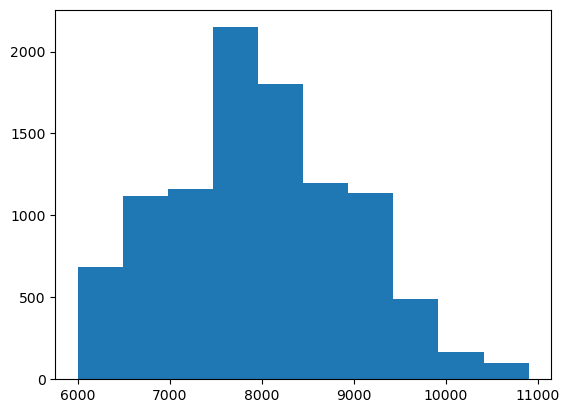

In [29]:
plt.hist(df["Price-$"])
plt.show()

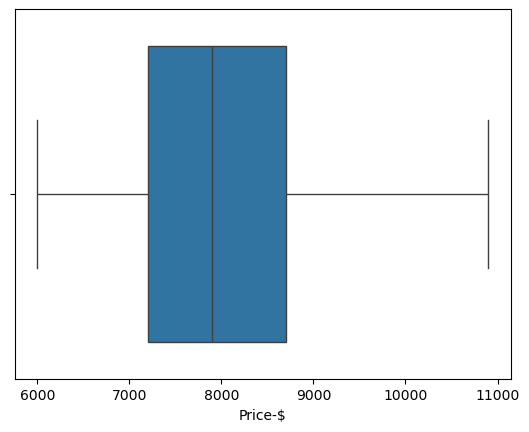

In [31]:
sns.boxplot(x=df["Price-$"])
plt.show()

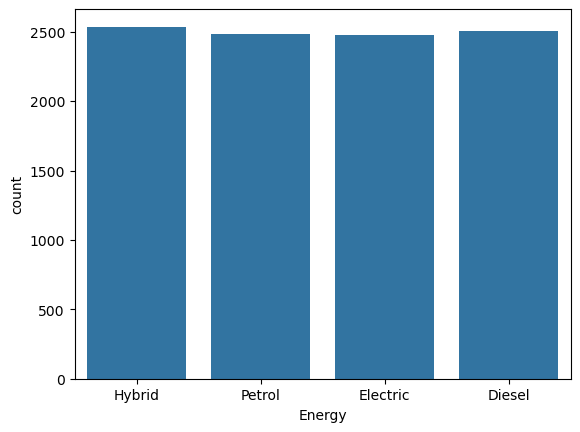

In [32]:
sns.countplot(x="Energy",data=df)
plt.show()

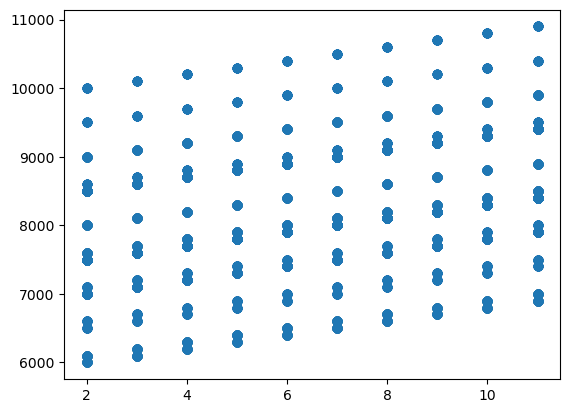

In [33]:
plt.scatter(df["Car_Age"],df["Price-$"])
plt.show()

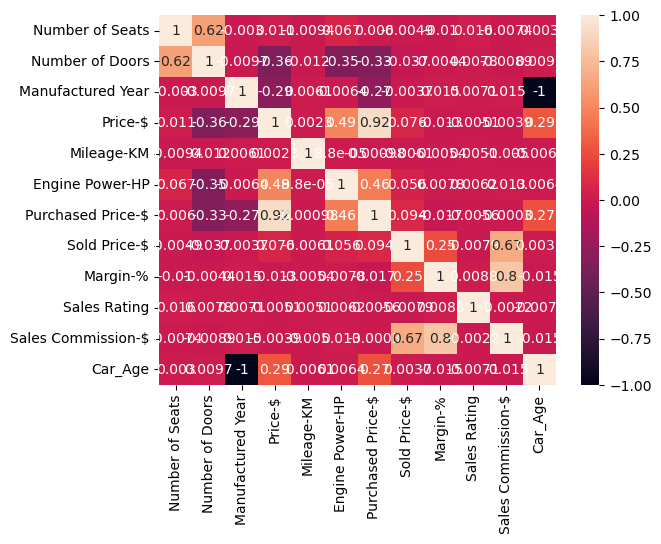

In [34]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
df.to_csv("Clean_dataset",index=False)

In [35]:
df[["Car_Age","Price-$"]].corr()

,Car_Age,Price-$
Car_Age,1.00000,0.29061
Price-$,0.29061,1.00000


In [36]:
df.groupby("Energy")["Sold Price-$"].mean().sort_values(ascending=False)

Energy
Electric    1738.950283
Hybrid      1487.142744
Petrol      1384.469593
Diesel      1342.866374
Name: Sold Price-$, dtype: float64

In [37]:
df.groupby("Gearbox")["Sold Price-$"].mean()

Gearbox
Automatic    1483.368349
Manual       1492.350927
Name: Sold Price-$, dtype: float64

In [38]:
df.sort_values(by="Sold Price-$",ascending=False).head(5)

,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,...,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback,Car_Age
6383,G83JIR,Carousell,Detroit,Plato,Prazo,Convertible,Black,Automatic,2,2,...,Sold,2021-08-04,10332,11657,13,Swapna,4,265,Poor,11
4673,ATNJLM,Motor,North Carolina,Plato,Prazo,Convertible,Red,Automatic,2,2,...,Sold,2022-09-08,10061,11382,13,Piyush,2,264,Excellent,8
9509,ADMDDE,Olx,Utah,Plato,Prazo,Convertible,White,Automatic,2,2,...,Sold,2023-07-14,10024,11075,10,Dhruv,4,210,Average,9
180,2NSSF5,Motor,Tennessee,Plato,Prazo,Convertible,Black,Automatic,2,2,...,Sold,2024-03-02,9637,10909,13,Bhavani,3,254,Good,8
3692,17FJF4,Marchi,Portland,Plato,Prazo,Convertible,Blue,Manual,2,2,...,Sold,2020-02-21,9711,10727,10,Aditya,1,203,Average,10


In [39]:
df["Energy"].value_counts(normalize=True)*100

Energy
Hybrid      25.36
Diesel      25.07
Petrol      24.83
Electric    24.74
Name: proportion, dtype: float64

In [40]:
df.groupby("Location")["Sold Price-$"].sum().sort_values(ascending=False)

Location
North Carolina    1620888
Tennessee         1047480
Tucson             966450
San Jose           898586
Texas              886580
Columbus           877438
Philadelphia       838016
Denver             829856
Chicago            827400
New York           811923
California         800944
Utah               797777
Florida            773390
Detroit            773032
Oklahoma           771115
Madison            746118
Portland           610768
Name: Sold Price-$, dtype: int64

In [41]:
df.groupby("Manufacturer Name")["Margin-%"].mean().sort_values(ascending=False)

Manufacturer Name
Prazo       0.644118
Tata        0.597590
Kia         0.544631
Toyota      0.466107
Maruti      0.421564
Renault     0.380531
Mahindra    0.314768
Hyundai     0.294855
Name: Margin-%, dtype: float64

In [42]:
df[["Engine Power-HP","Sold Price-$"]].corr()

,Engine Power-HP,Sold Price-$
Engine Power-HP,1.000000,0.056428
Sold Price-$,0.056428,1.000000


In [43]:
df.groupby("Car Sale Status")["Mileage-KM"].mean()

Car Sale Status
Sold       45146.978763
Un Sold    45594.455195
Name: Mileage-KM, dtype: float64

In [44]:
df["Purchased Date"]=pd.to_datetime(df["Purchased Date"])
df["Sold Date"]=pd.to_datetime(df["Sold Date"])

df["Days_to_sell"]=(df["Sold Date"]-df["Purchased Date"]).dt.days
df["Days_to_sell"].mean()

np.float64(-14134.899)

In [45]:
df["Profit"]=df["Sold Price-$"]-df["Purchased Price-$"]
df["Profit"].sum()

np.int64(-52328416)

In [46]:
df.groupby("Number of Seats")["Sold Price-$"].sum()

Number of Seats
2    1401254
3    1340796
4    3258922
5    6176829
7    1347132
8    1352828
Name: Sold Price-$, dtype: int64

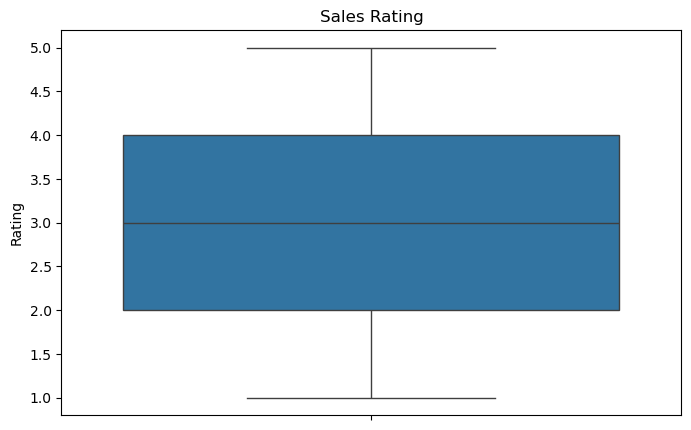

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(y="Sales Rating",data=df)
plt.title("Sales Rating")
plt.ylabel("Rating")
plt.show()

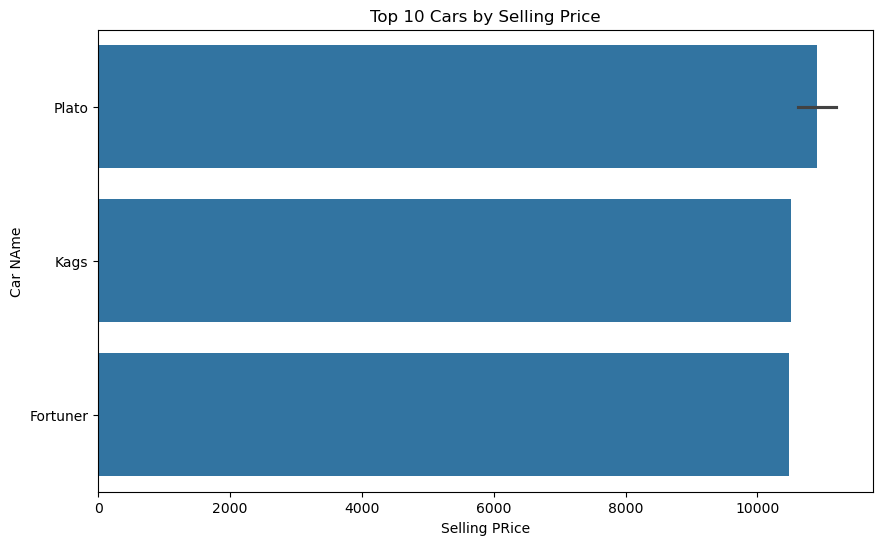

In [48]:
top_cars=df.sort_values("Sold Price-$",ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Sold Price-$",y="Car Name",data=top_cars)
plt.title("Top 10 Cars by Selling Price")
plt.xlabel("Selling PRice")
plt.ylabel("Car NAme")
plt.show()

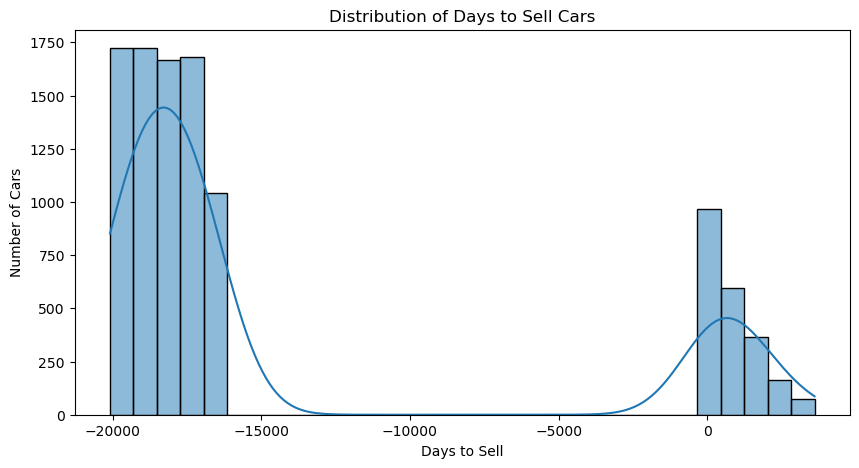

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(df['Days_to_sell'], bins=30, kde=True)
plt.title("Distribution of Days to Sell Cars")
plt.xlabel("Days to Sell")
plt.ylabel("Number of Cars")
plt.show()